In [32]:
#dependencies
!pip install kneed
# Load the required modules
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import scvi
from scipy.sparse import csr_matrix
from sklearn.decomposition import PCA
import warnings
import os
import pickle as pkl
from kneed import KneeLocator as kl
import os
import scanpy.external as sce
import anndata as ad

# Ignore the warning messages
warnings.filterwarnings("ignore")


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


## Visualization of Real and Synthetic Single-Cell Datasets Using UMAP

This notebook visualizes and compares the **real** single-cell RNA-seq dataset with three **synthetic** datasets generated by different models — **LVAE**, **scRDiT**, and **scDesign2**.  
The objective is to assess how well each generative model reproduces the **global transcriptional landscape** of the real data.  

### Visualization Strategy
- Each dataset is embedded using **UMAP** to represent cells in a low-dimensional space that preserves biological structure.  
- Cells are colored by **cell type**, using a **shared color palette** across all datasets to ensure consistent visual comparison.  
- This side-by-side representation allows evaluation of:
  - How accurately synthetic datasets capture **cell-type separation and organization**.  
  - Whether spurious clusters or distortions appear in model-generated data.  

### Goal
By comparing the UMAP embeddings of real and synthetic data under the same color scheme, we can **visually inspect the structural fidelity** of each generative model and its ability to preserve true cell-type heterogeneity.


In [33]:
def load_and_merge(folder: str, filetype: str = ".h5ad") -> ad.AnnData:
    """
    Load and merge multiple AnnData (.h5ad) files from a given folder.

    This function scans a directory for all files with the specified extension,
    loads each one as an AnnData object, and concatenates them into a single
    AnnData object.

    Parameters
    ----------
    folder : str
        Path to the folder containing the files to load.
    filetype : str, optional
        File extension to look for (default: '.h5ad').

    Returns
    -------
    AnnData
        A single merged AnnData object containing all loaded datasets.
    """
    adatas = []
    fnames = sorted([f for f in os.listdir(folder) if f.endswith(filetype)])

    for fname in fnames:
        path = os.path.join(folder, fname)
        print(f"Loading: {path}")
        adata = sc.read(path)
        adatas.append(adata)
        
    adata_merged = ad.concat(adatas, join="outer", fill_value=0)

    return adata_merged

In [34]:
# Define new function that finds the elbow dimension 
def PCA_Elbow_fit(data):
    model = PCA().fit(data)
    explained_variance = model.explained_variance_ratio_
    pcs = list(range(1, explained_variance.shape[0]+1))#enumerate(explained_variance,1)
    klm = kl(pcs, explained_variance, S=1.0, curve='convex', direction='decreasing')
    pcs_used = klm.knee
    pc_list = list(range(1, pcs_used+1))
    new_data = PCA(n_components= pcs_used, svd_solver='arpack').fit_transform(data)

    if pcs_used >50:
        pcs_used=50
        
    return pcs_used, new_data, pcs, explained_variance, pc_list

In [35]:
def plot_umap(adata, palette_dict, save_path):
    """
    Compute and plot a UMAP embedding of an AnnData object colored by cell type.

    This function performs PCA for dimensionality reduction, automatically selects
    the optimal number of principal components using the elbow method, computes
    a neighbor graph, and visualizes the UMAP embedding with a consistent color
    palette across datasets.

    Parameters
    ----------
    adata : AnnData
        The single-cell dataset to visualize.
    palette_dict : dict
        Dictionary mapping each cell type to a consistent color.
    save_path : str
        Path or suffix to save the resulting UMAP plot.

    Returns
    -------
    None
        The UMAP plot is displayed or saved to disk.
    """

    # Ensure dense representation of the expression matrix
    adata.X = np.asarray(adata.X)

    # Perform Principal Component Analysis (PCA) to reduce dimensionality
    sc.tl.pca(adata, svd_solver='arpack')

    # Extract the cell-by-gene expression matrix from the AnnData object
    # and convert it into a pandas DataFrame for variance-based PC selection
    new_frame = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
    pandas_data = new_frame.values

    # Determine the optimal number of principal components using the elbow method
    dim, new_matrix, pc_ax, pc_ay, col_labels = PCA_Elbow_fit(pandas_data)
    print(f"Optimal number of PCs: {dim}")

    # Compute neighborhood graph and generate UMAP embedding
    sc.pp.neighbors(adata, n_pcs=dim)
    sc.tl.umap(adata)

    # Plot the UMAP colored by cell type, using the provided consistent palette
    sc.pl.umap(
        adata,
        color=["cell_type"],
        frameon=False,
        title=" ",
        palette=[palette_dict[ct] for ct in adata.obs["cell_type"].cat.categories],
        save=save_path,
        show=True  
    )



### ADATA REAL

In [36]:
adata = sc.read_h5ad("/home/app/datos/PENG/adata_raw_anotado_peng_julio.h5ad")
adata.obs["cell_origin"] = "real"

In [37]:
palette_dict = {'Acinar cell': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'B cell': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 'CAF': (1.0, 0.4980392156862745, 0.054901960784313725),
 'Dendritic cells': (1.0, 0.7333333333333333, 0.47058823529411764),
 'Ductal cell': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'Endocrine cells': (0.596078431372549,
  0.8745098039215686,
  0.5411764705882353),
 'Endothelial cells': (0.8392156862745098,
  0.15294117647058825,
  0.1568627450980392),
 'Fibroblast': (1.0, 0.596078431372549, 0.5882352941176471),
 'Macrophages': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'Mast cells': (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 'Monocytes': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 'Plasma cells': (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
 'Proliferative cells': (0.8901960784313725,
  0.4666666666666667,
  0.7607843137254902),
 'Ribosomal cells': (0.9686274509803922,
  0.7137254901960784,
  0.8235294117647058),
 'T CD4 Reg': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 'T CD4': (0.7803921568627451, 0.7803921568627451, 0.7803921568627451),
 'T CD8': (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 'Tumoral - Classical':  (0.8588235294117647,
  0.8588235294117647,
  0.5529411764705883),
 'Tumoral - Basal-like': (0.09019607843137255,
  0.7450980392156863,
  0.8117647058823529)}

In [38]:
# qc filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalization of gene expression counts across cells
adata.layers['counts'] = csr_matrix(adata.X) 
adata.raw = adata 
sc.pp.normalize_total(adata, target_sum=1e4) 
sc.pp.log1p(adata)

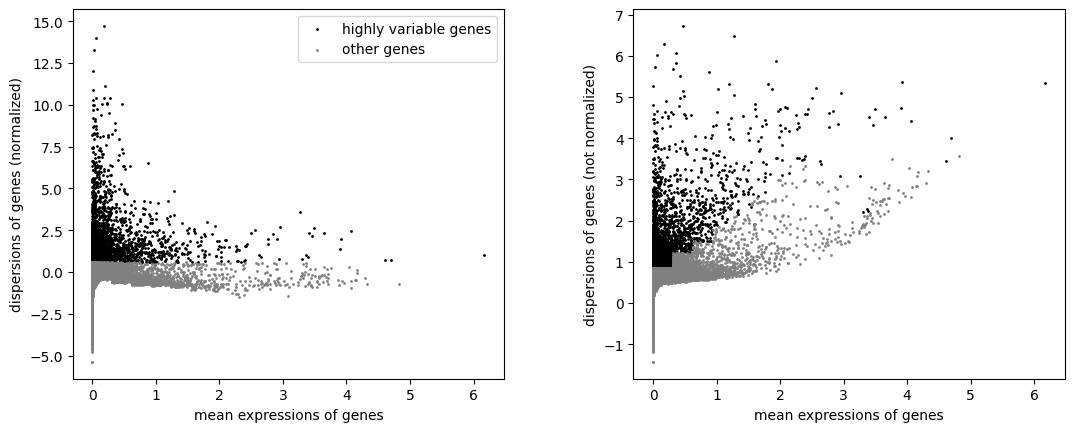

In [39]:
# Record highly variable genes (HVGs)
sc.pp.highly_variable_genes(adata,n_top_genes=3000)
sc.pl.highly_variable_genes(adata)
adata = adata[:, adata.var.highly_variable].copy()

Optimal number of PCs: 50


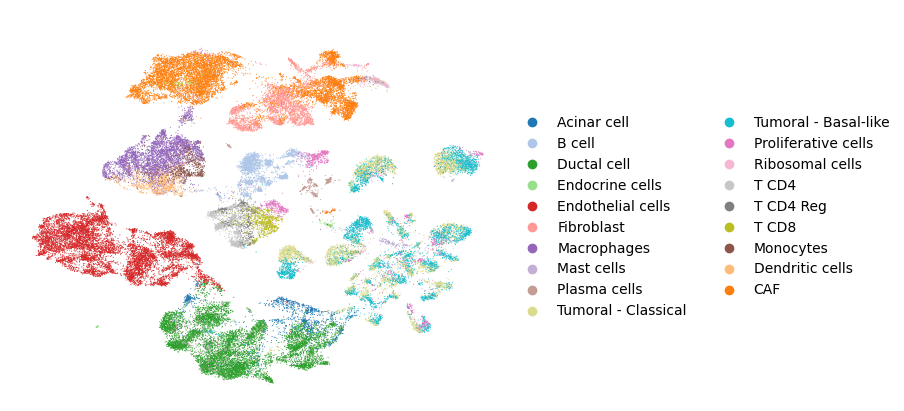

In [40]:
# Generate UMAP visualization for real dataset using a shared palette 
plot_umap(adata, palette_dict, save_path="real")

In [41]:
##################################################################################

### ADATA LVAE

In [42]:
adata_lvae = load_and_merge("/home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/codigo_github/adatas_nueva_prueba")
adata_lvae.obs["cell_origin"] = "synthetic"

Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/codigo_github/adatas_nueva_prueba/Acinar cell_syn.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/codigo_github/adatas_nueva_prueba/B cell_syn.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/codigo_github/adatas_nueva_prueba/CAF_syn.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/codigo_github/adatas_nueva_prueba/Dendritic cells_syn.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/codigo_github/adatas_nueva_prueba/Ductal cell_syn.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/codigo_github/adatas_nueva_prueba/Endocrine cells_syn.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/codigo_github/adatas_nueva_prueba/Endothelial cells_syn.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/codigo_github/

In [43]:
# Clean cell type labels in LVAE AnnData object
# Remove the suffix " Cholesky" from all cell type names to standardize nomenclature.
adata_lvae.obs["cell_type"] = (
    adata_lvae.obs["cell_type"]
    .astype(str)              
    .str.replace(" Cholesky", "", regex=False)
)

# Convert back to categorical to preserve a clean, ordered representation of cell types.
adata_lvae.obs["cell_type"] = pd.Categorical(adata_lvae.obs["cell_type"])

Optimal number of PCs: 50


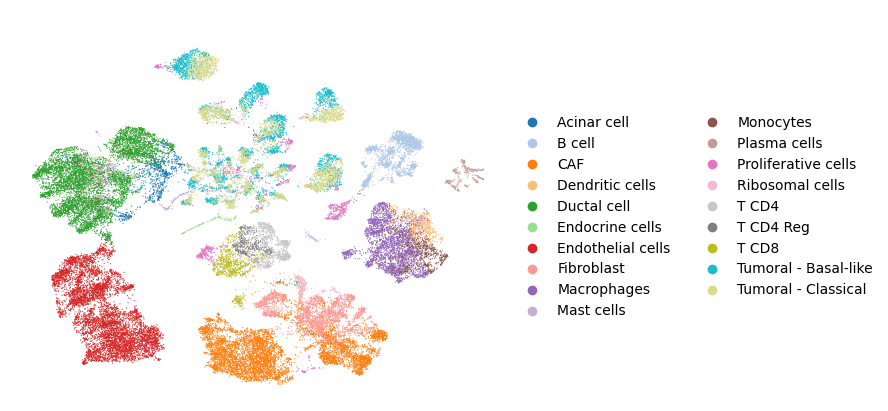

In [44]:
# Generate UMAP visualizations for LVAE-generated dataset using a shared palette
plot_umap(adata_lvae, palette_dict, save_path=None)

In [45]:
#######################################################################

### ADATA scdesign2

In [20]:
adata_scdesign2 = sc.read_h5ad("/home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/sim_count_copula.h5ad")
adata_scdesign2.obs["cell_origin"] = "synthetic"
adata_scdesign2.obs["Sample"] = "synthetic"

In [21]:
# Normalization of gene expression counts across cell
sc.pp.normalize_total(adata_scdesign2, target_sum=1e4)
sc.pp.log1p(adata_scdesign2)

Optimal number of PCs: 44


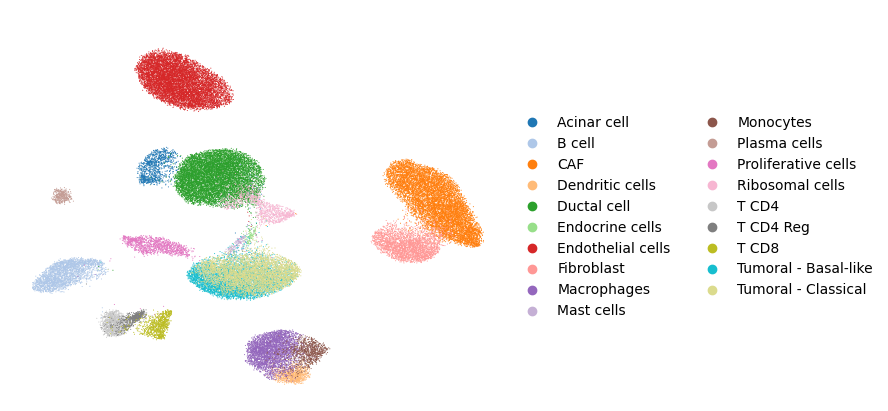

In [30]:
# Generate UMAP visualizations for scDesign2-generated dataset using a shared palette
plot_umap(adata_scdesign2, palette_dict, save_path="scdesign2")

In [23]:
########################################################################################################

### ADATA scrdit

In [24]:
adata_scrdit = load_and_merge("/home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit")
adata_scrdit.obs["cell_origin"] = "synthetic"

Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/CAF_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/T_CD4_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/T_CD4_reg_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/T_CD8_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/Tumoral_-_Basal-like_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/Tumoral_-_Classical_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/acinar_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/b_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/dendritic_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/ductal_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/endocrine_dit_.

In [25]:
# Standardize cell type nomenclature in the scRDiT-generated dataset 
# Rename cell type categories to match the reference annotation used in the real dataset

adata_scrdit.obs["cell_type"] = adata_scrdit.obs["cell_type"].cat.rename_categories({
    "Acinar cell scRDit": "Acinar cell",
    "B cell scRDit": "B cell",
    "CAF scRDit": "CAF",
    "Dendritic cell scRDit":"Dendritic cells",
    "Ductal cell scRDit":"Ductal cell",
    "Endocrine cell scRDit":"Endocrine cells",
    "Endothelial cell scRDit":"Endothelial cells",
    "Fibroblast cell scRDit": "Fibroblast",
    "Macrophages cell scRDit":"Macrophages",
    "Mast cell scRDit": "Mast cells",
    "Monocytes scRDit":"Monocytes",
    "Plasma cell scRDit":"Plasma cells",
    "Proliferative cell scRDit": "Proliferative cells",
    "Ribosomal cell scRDit": "Ribosomal cells",
    "T CD4 Reg cell scRDit":"T CD4 Reg",
    "T CD4 cell scRDit":"T CD4",
    "T CD8 cell scRDit":"T CD8", 
    "Tumoral-Basal-like cell scRDit":'Tumoral - Basal-like',
    "Tumoral-Classical cell scRDit":"Tumoral - Classical", 
})

Optimal number of PCs: 36


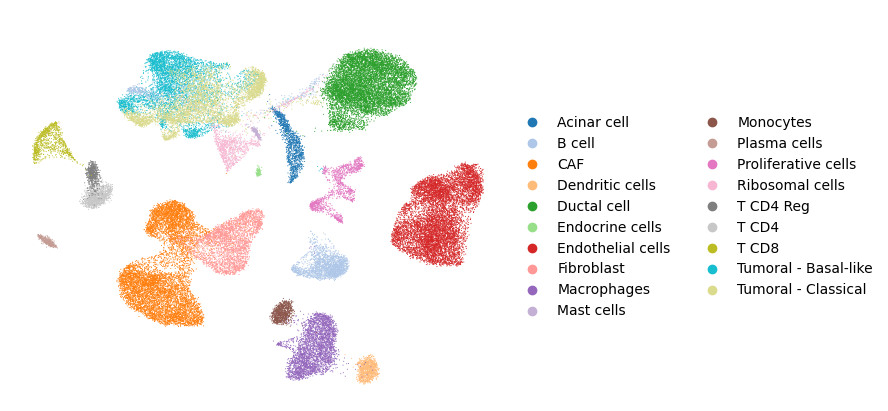

In [31]:
# Generate UMAP visualizations for scRDiT-generated dataset using a shared palette
plot_umap(adata_scrdit, palette_dict, save_path="scrdit")